In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.negloglik_params import *

from dekef.negloglik_grid_points import *
from dekef.scorematching_penalized_grid_points import *

from dekef.plot_density_1d import *

from IPython.display import Markdown as md

import warnings
warnings.filterwarnings('ignore')
np.random.seed(1989)

from matplotlib import gridspec
import seaborn as sns

In [3]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
# waiting = waiting[waiting != 108.0]
# contam_pt = 120.

In [20]:
def kernel_fun(x, center, bw): 
    
    # assert len(center) == 1
    assert bw > 0.
    
    x = np.array(x)
    
    output = np.exp(-(x - center) ** 2 / (2 * bw ** 2))
    
    return output

In [ ]:
# set plot parameters
xlimit = (1., 200.) # (25., 125.)

plot_pts_cnt = 3000
ylimit = (-0.02, 1.105)

var_name = 'waiting'

label_fontsize = 20
tick_fontsize = 18
info_fontsize = 35
ncols = 1
nrows = 1

fig = plt.figure(constrained_layout=False)
spec = gridspec.GridSpec(ncols=ncols, nrows=nrows, figure=fig)
fig.set_figheight(10)
fig.set_figwidth(10)

ax = fig.add_subplot(spec[0, 0])

center_list = np.arange(1., 181., 1)
spread = 150.
bw = 5.
for i in center_list: 
    
    center = i.item()
    x = np.linspace(i - spread, i + spread, plot_pts_cnt)
    kernel_eval = kernel_fun(x, center, bw)
    plt.plot(x, kernel_eval, color = 'tab:blue', alpha = 0.5)

# ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
#                                        bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
# plot the histogram of waiting variable 
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = label_fontsize)
ax.set_ylabel(r'$k \ (w_j, \,\cdot\,)$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')

# ax.axvline(x = 20., color = 'indigo', alpha = 1., linestyle = 'dashed')
# ax.axvline(x = 60., color = 'tab:brown', alpha = 1., linestyle = 'dashed')
# ax.axvline(x = 80., color = 'tab:brown', alpha = 1., linestyle = 'dashed')
# # ax.axvline(x = 120., color = 'indigo', alpha = 1., linestyle = 'dashed')
# ax.axvline(x = 150., color = 'indigo', alpha = 1., linestyle = 'dashed')
# ax.axvline(x = 200., color = 'indigo', alpha = 1., linestyle = 'dashed')

# width, height = 3.2, 0.025
# ax.add_patch(ax.add_artist(Ellipse((20., 0.), width, height, color = 'indigo', fill = False, linewidth = 3.0)))
# ax.add_patch(ax.add_artist(Ellipse((60., 0.), width, height, color = 'tab:brown', fill = False, linewidth = 3.0)))
# ax.add_patch(ax.add_artist(Ellipse((80., 0.), width, height, color = 'tab:brown', fill = False, linewidth = 3.0)))
# # ax.add_patch(ax.add_artist(Ellipse((120., 0.), width, height, color = 'indigo', fill = False, linewidth = 3.0)))
# ax.add_patch(ax.add_artist(Ellipse((150., 0.), width, height, color = 'indigo', fill = False, linewidth = 3.0)))
# ax.add_patch(ax.add_artist(Ellipse((200., 0.), width, height, color = 'indigo', fill = False, linewidth = 3.0)))

plt.tight_layout()

# plt.savefig(f'../plots/waiting-basis-functions.pdf', bbox_inches = 'tight')

In [ ]:
# set plot parameters
font_size = 15
xlimit = (11., 109.)
plot_pts_cnt = 3000
ylimit = (-0.001, 0.0451)

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
                                       bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)
ax.axvline(x = 20., color = 'tab:purple', alpha = 1., linestyle = 'dashed')
ax.axvline(x = 60., color = 'tab:brown', alpha = 1., linestyle = 'dashed')
ax.axvline(x = 80., color = 'tab:brown', alpha = 1., linestyle = 'dashed')

# plt.savefig(f'../plots/histogram-xlimit={xlimit}-20-60-80.pdf', bbox_inches = 'tight')

In [ ]:
# set plot parameters
font_size = 15
xlimit = (25., 125.)
xticks = [40, 60, 80, 100, 120]

plot_pts_cnt = 3000
ylimit = (-0.001, 0.0501)

label_fontsize = 25
tick_fontsize = 22
info_fontsize = 35

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
                                       bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')

ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = label_fontsize)
ax.set_ylabel('density', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)

plt.savefig('../plots/geyser-waiting-histogram.pdf', bbox_inches = 'tight')

In [3]:
base_density = BasedenGamma(waiting, 36., 2.)
base_density.a, base_density.scale

(36.0, 2.0)

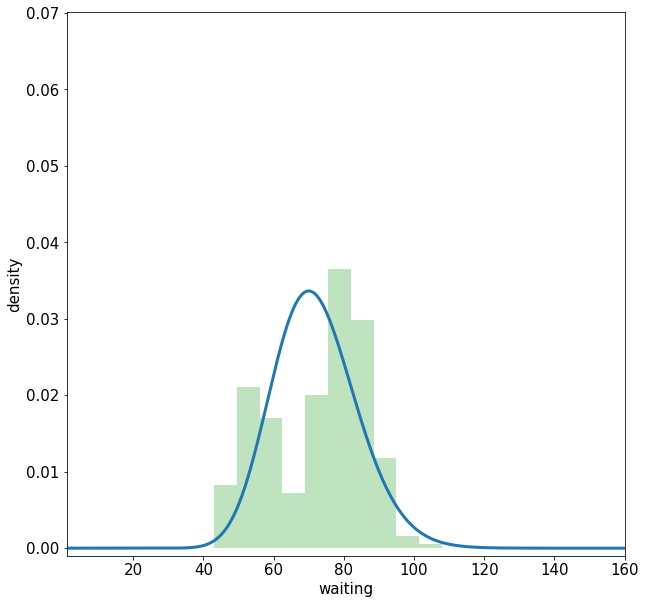

In [5]:
# set plot parameters
font_size = 15
xlimit = (1., 160.)
plot_pts_cnt = 3000
ylimit = (-0.001, 0.0701)

# set plot parameters
new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)
base_den_vals = base_density.baseden_eval(new_data.reshape(-1, 1))

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
                                       bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
# ax.set_xlim(xlimit)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)
ax.plot(new_data, base_den_vals, color = 'tab:blue', linewidth = 3.0)

# plt.savefig('../plots/histogram_base1.pdf')

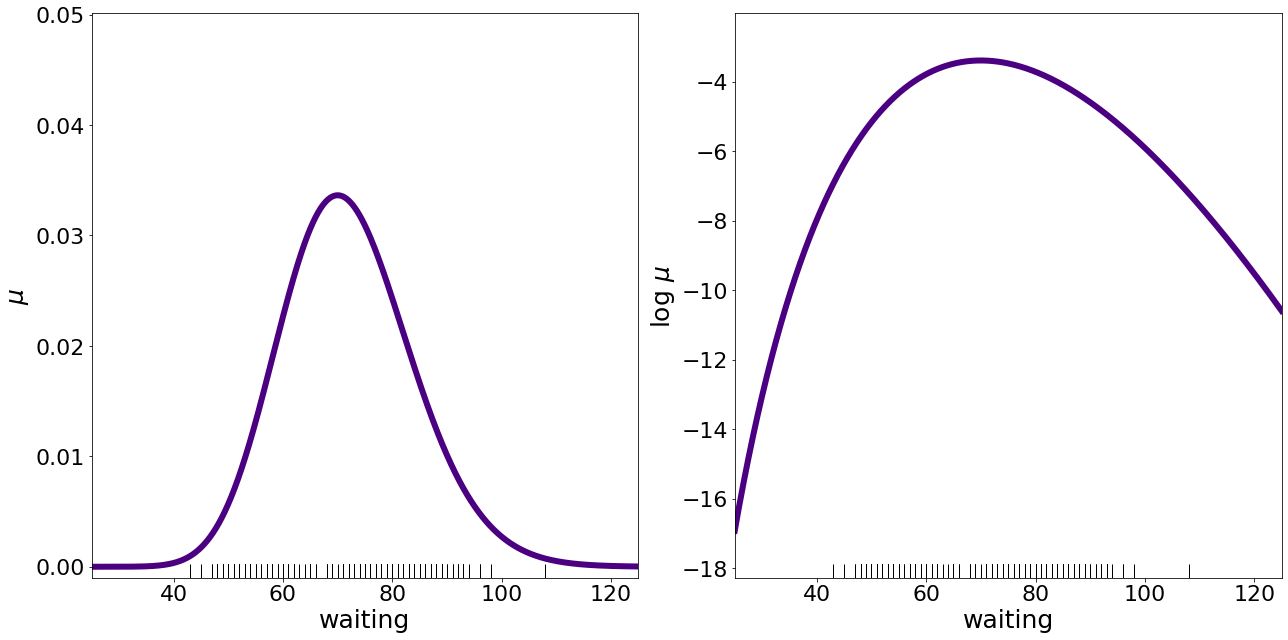

In [6]:
from matplotlib import gridspec
import seaborn as sns

info_coord = (0.98, 0.98)
horizontalalignment, verticalalignment = 'right', 'top'
xticks = [40, 60, 80, 100, 120]

# set plot parameters
xlimit = (25., 125.)
new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)
base_den_vals = base_density.baseden_eval(new_data.reshape(-1, 1))
base_logderiv1 = base_density.logbaseden_deriv1(new_data.reshape(-1, 1))

fig = plt.figure(constrained_layout=False)

fig.set_figheight(9)
fig.set_figwidth(18)
ncols = 2
nrows = 1
linewidth = 6.0
var_name = 'waiting'

label_fontsize = 25
tick_fontsize = 22
info_fontsize = 35

spec = gridspec.GridSpec(ncols=ncols, nrows=nrows, figure=fig)

ax = fig.add_subplot(spec[0, 0])
ax.plot(new_data.flatten(), base_den_vals, color = 'indigo', linewidth = linewidth)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')
ax.set_xlabel(var_name, fontsize = label_fontsize)
ax.set_ylabel(r'$\mu$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax.set_title('Base density', fontsize = info_fontsize)
ax.set_xlim(xlimit)
ax.set_ylim(-0.001, 0.0501)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65))
# ax.text(*info_coord,
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

ax = fig.add_subplot(spec[0, 1])
ax.plot(new_data.flatten(), np.log(base_den_vals), color = 'indigo', linewidth = linewidth)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')
ax.set_xlabel(var_name, fontsize = label_fontsize)
ax.set_ylabel(r'$\log \ \mu$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax.set_title('Log base density', fontsize = info_fontsize)
ax.set_xlim(xlimit)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(66))
# ax.text(*info_coord,
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

# ax = fig.add_subplot(spec[0, 2])
# ax.plot(new_data.flatten(), base_logderiv1.flatten(), color = 'tab:blue', linewidth = linewidth)
# sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')
# ax.set_ylabel(r"$(\log \, \mu)'$", fontsize = label_fontsize)
# ax.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax.set_xlabel(var_name, fontsize = label_fontsize)
# # ax.axhline(0., 0, 1, ls = '--', color = 'tab:purple', alpha = 1.)
# ax.set_title('First derivative of log base density', fontsize = info_fontsize)
# ax.set_xlim(31., 120.)

plt.tight_layout()

plt.savefig(f'../plots/baseden-logbaseden-Gamma-{base_density.a}-{base_density.scale}.pdf', 
            bbox_inches = 'tight')

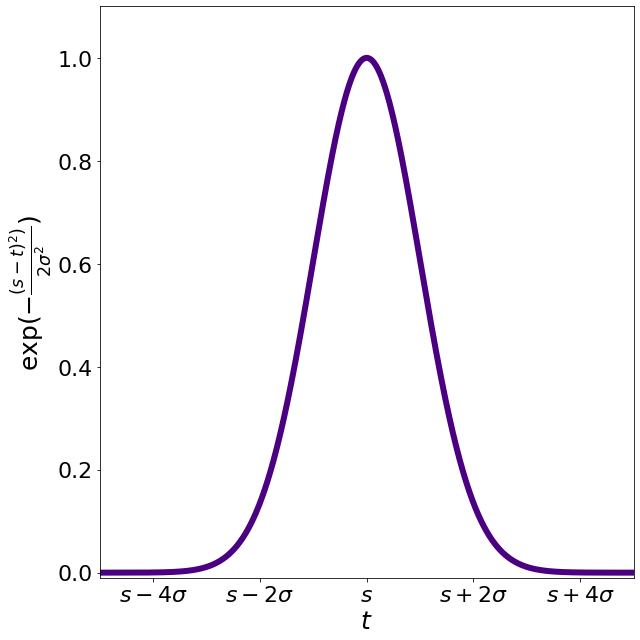

In [24]:
from matplotlib import gridspec
import seaborn as sns

info_coord = (0.98, 0.98)
horizontalalignment, verticalalignment = 'right', 'top'
xticks = [-20, -10, 0, 10, 20]
xticks1 = [r'$s-4\sigma$', r'$s-2\sigma$', r'$s$', r'$s+2\sigma$', r'$s+4\sigma$']

# set plot parameters
xlimit = (-25., 25.)
new_data = np.linspace(-25., 25., 2000)
vals = kernel_fun(x = new_data, center = 0., bw = 5.)

fig = plt.figure(constrained_layout=False)

fig.set_figheight(9)
fig.set_figwidth(9)
ncols = 1
nrows = 1
linewidth = 6.0
var_name = 'x'

label_fontsize = 25
tick_fontsize = 22
info_fontsize = 35

spec = gridspec.GridSpec(ncols=ncols, nrows=nrows, figure=fig)

ax = fig.add_subplot(spec[0, 0])
ax.plot(new_data.flatten(), vals, color = 'indigo', linewidth = linewidth)
ax.set_xlabel(r'$t$', fontsize = label_fontsize)
ax.set_ylabel(r'$\exp (-\frac{(s-t)^2)}{2\sigma^2} )$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax.set_title('Base density', fontsize = info_fontsize)
ax.set_xlim(xlimit)
ax.set_ylim(-0.01, 1.1)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks1, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65))
# ax.text(*info_coord,
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/gaussian-kernel.pdf', bbox_inches = 'tight')

In [26]:
np.exp(-12.5)

3.726653172078671e-06

In [25]:
vals

array([3.72665317e-06, 3.82099382e-06, 3.91762468e-06, ...,
       3.91762468e-06, 3.82099382e-06, 3.72665317e-06])